# Homework 4
### Grupo 127
#### André Melo (ist1106937) e Gonçalo Aleixo (ist1106900)

## II. Programming and critical analysis [11v]

**In the next exercise you will use the accounts.csv dataset. This dataset contains account details**
**of bank clients, and the target variable y is binary (‘has the client subscribed a term deposit?’).**
**Select the first 8 features and remove duplicates and null values.**

**Hint: You can use get_dummies() to change the feature type (e.g. pd.get_dummies(data, drop_first=True)).**

**1. Normalize the data using MinMaxScaler:**

**a. [4v] Using sklearn, apply k-means clustering (without targets) on the normalized**
**data with k={2,3,4,5,6,7,8}, max_iter=500 and random_state=42. Plot the diﬀerent sum of squared errors (SSE) using the _inertia** **attribute of k-means according to the number of clusters.**

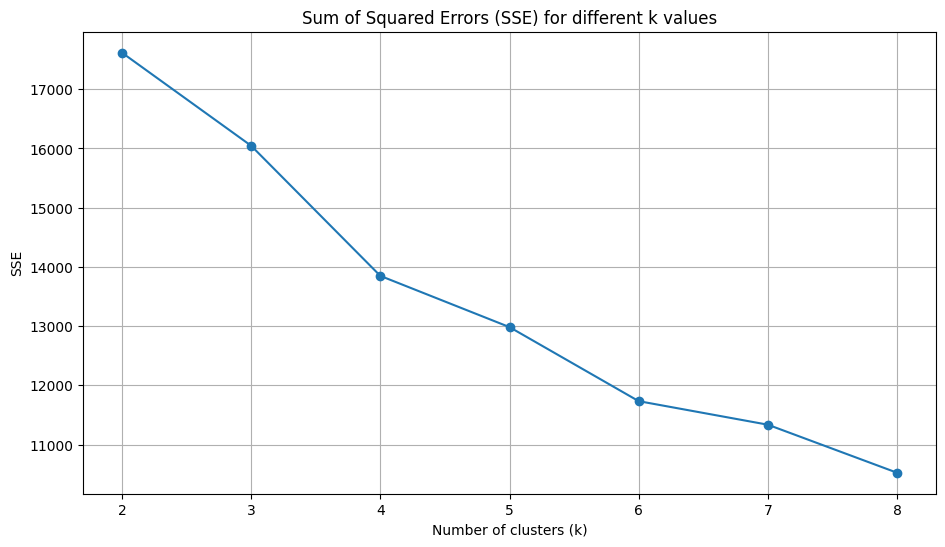

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

#Load the dataset
df = pd.read_csv('accounts.csv')

#Select the first 8 features and remove duplicates and null values
selected_columns = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan']
df_filtered = df[selected_columns].drop_duplicates().dropna()

#Convert categorical variables to numerical using get_dummies()
df_dummies = pd.get_dummies(df_filtered, drop_first=True)

#Normalize the data using MinMaxScaler
scaler = MinMaxScaler()
df_normalized = scaler.fit_transform(df_dummies)

k_values = [2, 3, 4, 5, 6, 7, 8]
sse = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, max_iter=500, random_state=42)
    kmeans.fit(df_normalized)
    sse.append(kmeans.inertia_)  # store the inertia (SSE)

#Plot the SSE for each value of k
plt.figure(figsize=(11, 6))
plt.plot(k_values, sse, marker='o')
plt.title('Sum of Squared Errors (SSE) for different k values')
plt.xlabel('Number of clusters (k)')
plt.ylabel('SSE')
plt.grid(True)
plt.show()

**b. [1.5v] According to the previous plot, how many underlying customer segments**
**(clusters) should there be? Explain based on the trade-oﬀ between the clusters and**
**inertia.**

Com base no gráfico acima que representa o Sum of Squared Errors (SSE) em função do número de clusters (k), de acordo com o método "elbow", o número ideal de segmentos parece ser 4, já que o SSE diminui a um ritmo menor após esse ponto.

À medida que aumentamos o número de clusters, a inércia continua a diminuir porque os dados dentro de cada cluster ficam mais próximos do seu centro. No entanto, esta diminuição não é infinita nem linear. Após um certo número de clusters, como 4 ou 6 no gráfico, a redução na inércia torna-se cada vez menor. Este ponto, onde a redução adicional de inércia já não justifica o aumento no número de clusters, é o que chamamos de "elbow". A partir deste ponto, adicionar mais clusters aumenta a complexidade do modelo sem oferecer melhorias significativas, tornando-o mais difícil de interpretar e possivelmente mais sujeito a capturar noise e overfitting nos dados.

O cotovelo mais pronunciado aparece em k=4, pois é onde a queda mais acentuada no SSE começa a nivelar-se. Embora k=6 mostre outra queda no ritmo de diminuição do SSE, a melhoria não é tão significativa. Portanto, 4 clusters parece ser o número ideal, já que proporciona um bom equilíbrio entre a redução do SSE e a simplicidade do modelo.

**c. [1.5v] Would k-modes be a better clustering approach? Explain why based on the**
**dataset features.**

Enquanto que o k-means agrupa pontos calculando a média dos valores em cada cluster, minimizando a distância euclidiana entre os pontos e o centro do cluster, sendo ideal para dados numéricos, o k-modes é projetado para trabalhar com dados categóricos. Utilizando a moda (valor mais frequente) para definir o centro do cluster, torna-o mais eficiente e interpretável em casos onde os dados não são puramente numéricos.

Sendo que o nosso dataset (accounts.csv) tem um elevado número de variáveis categóricas, o k-modes seria uma abordagem mais apropriada. 

**2. Normalize the data using StandardScaler:**

**a. [1v] Apply PCA to the data. How much variability is explained by the top 2**
**components?**

In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#Normalize the data using StandardScaler
scaler = StandardScaler()
df_normalized = scaler.fit_transform(df_dummies)

#Apply PCA to the normalized data
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_normalized)

#Get the explained variance ratio for the top 2 components
explained_variance = pca.explained_variance_ratio_

print(f"Explained Variance by Component 1: {explained_variance[0]:.4%}")
print(f"Explained Variance by Component 2: {explained_variance[1]:.4%}")
print(f"Explained Variance by Top 2 Components: {explained_variance[0] + explained_variance[1]:.4%}")

Explained Variance by Component 1: 11.6790%
Explained Variance by Component 2: 11.0760%
Explained Variance by Top 2 Components: 22.7550%


**b. [1v] Apply k-means clustering with k=3 and random_state=42 (all other**
**arguments as default) and use the original 8 features. Next, provide a scatterplot**
**according to the first 2 principal components. Can we clearly separate the clusters?**
**Justify.**

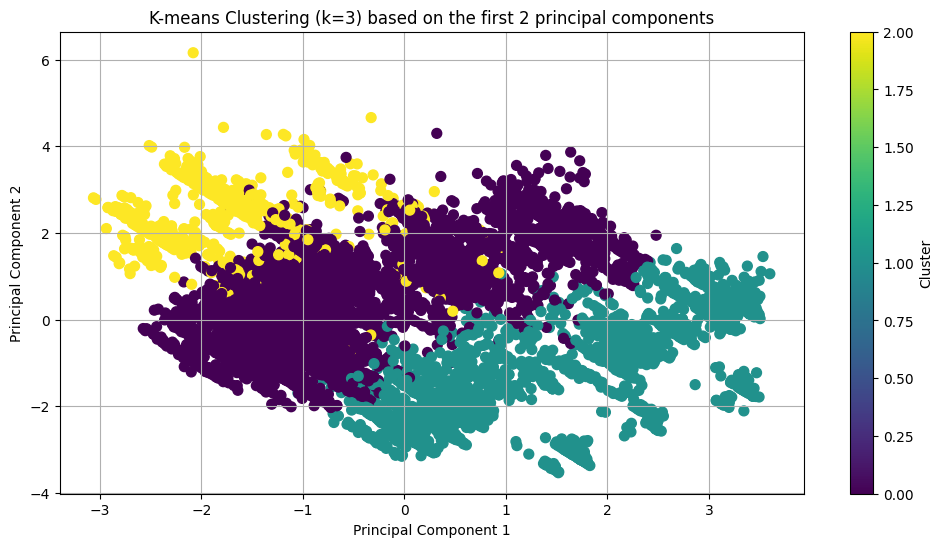

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df_normalized)

plt.figure(figsize=(12, 6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=clusters, cmap='viridis', s=50)
plt.title('K-means Clustering (k=3) based on the first 2 principal components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

Com base no gráfico, os clusters não são totalmente separáveis quando projetados nos dois primeiros componentes principais, já que todos os clusters apresentam uma sobreposição significativa. Isto indica que não há uma fronteira clara entre eles neste espaço bidimensional. Esta sobreposição sugere que os dois primeiros componentes principais não capturam toda a variabilidade dos dados, e que seriam necessárias mais dimensões (componentes principais adicionais) para uma separação mais nítida dos clusters.

**c. [2v] Plot the cluster conditional features of the frequencies of “job” and ”education”**
**according to the clusters obtained in the previous question (2b.). Use sns.distplot**
**(see Data Exploration notebook), with multiple="dodge", stat='density', shrink=0.8 and common_norm=False. Describe the main diﬀerences** **between the clusters in no more than half a page.**

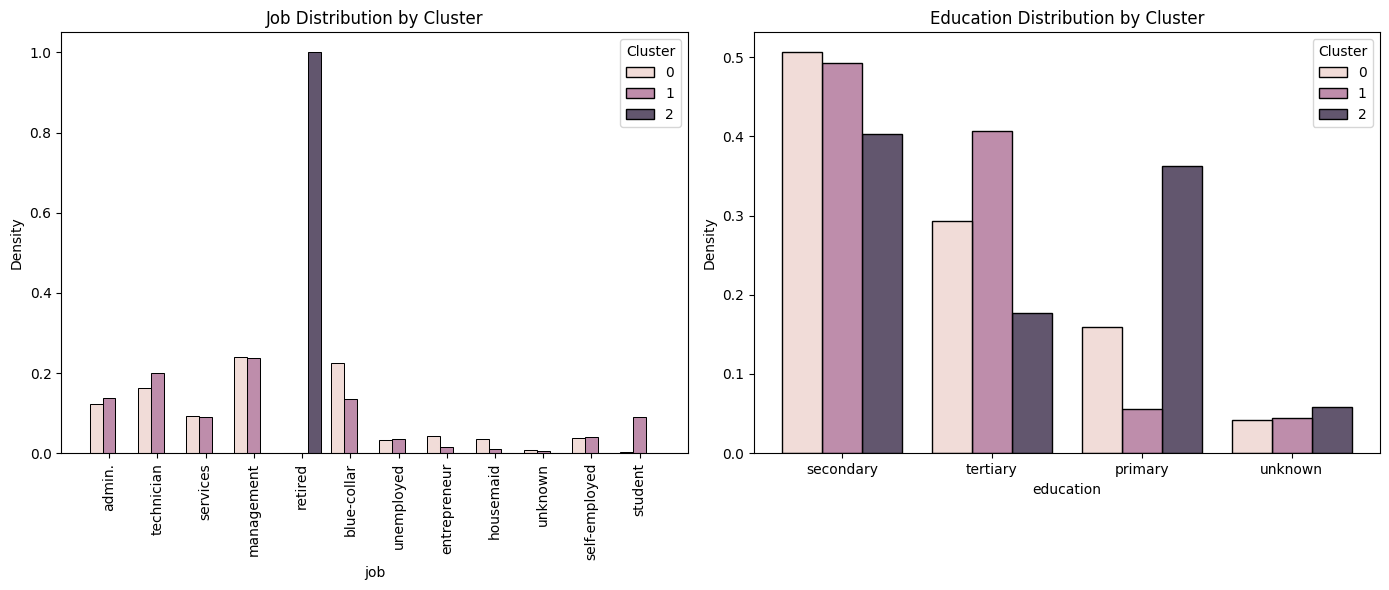

In [7]:
import seaborn as sns

#Add the cluster labels to the filtered data for grouping
df_filtered['Cluster'] = clusters

plt.figure(figsize=(14, 6))

#Plot for "job" distribution by cluster
plt.subplot(1, 2, 1)
sns.histplot(data=df_filtered, x='job', hue='Cluster', multiple='dodge', stat='density', shrink=0.8, common_norm=False)
plt.title('Job Distribution by Cluster')
plt.xticks(rotation=90)

#Plot for "education" distribution by cluster
plt.subplot(1, 2, 2)
sns.histplot(data=df_filtered, x='education', hue='Cluster', multiple='dodge', stat='density', shrink=0.8, common_norm=False)
plt.title('Education Distribution by Cluster')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Distribuição de Profissões (Job):

- Cluster 2: Este cluster é claramente dominado por clientes "reformados", o que o diferencia dos outros clusters que têm distribuições de profissões mais diversificadas. Isso sugere que o Cluster 2 representa um segmento de clientes com uma faixa etária mais avançada ou que já não está no mercado de trabalho ativo.
- Cluster 0: Este cluster apresenta uma diversidade maior de profissões, com maior densidade de clientes em "blue-collar", "management". Este grupo parece representar uma faixa de clientes empregados em ocupações operacionais e administrativas.
- Cluster 1: Mostra uma presença de clientes nas áreas de "management" e "technician", e uma leve concentração em "students" e "self-employed" . Este cluster pode representar um grupo mais jovem e diversificado, com alguns ainda a estudar ou a trabalhar por conta própria.

Distribuição de Educação (Education):

- Cluster 2: Além de ser dominado por "reformados", este cluster também tem uma grande proporção de clientes com "educação primária", o que sugere um perfil de escolaridade mais baixo entre os clientes deste grupo, pondendo ter relação com a faixa etária.
- Cluster 0: Tem a concentração mais alta na educação secundária e parece ser o cluster com maior nível de educação.
- Cluster 1: Tem uma representação mais equilibrada entre educação "secondary" e "tertiary", indicando que inclui clientes com variados níveis de escolaridade. A maior densidade em "educação secundária" sugere um grupo com escolaridade média.

Os três clusters diferem tanto em termos de profissões quanto de nível educacional. O Cluster 2 é claramente caracterizado por clientes "reformados" com menor escolaridade. O Cluster 0 e o Cluster 1 abrangem uma grande diversidade de profissões, diferenciando-se na alta concentração de "blue-collar" no cluster 0 e na alta concentração de "student" no cluster 1. Na educação, a concentração de "secondary" é muito semelhante entre o Clusters 0 e 1. O Cluster 1 apresenta uma concentração mais alta de clientes com educação terciária "tertiary" e o cluster 0 tem uma concentração mais alta de educação primária "primary".






